In [1]:
!pip install graphviz


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


=== Activity on Node (AON) ===


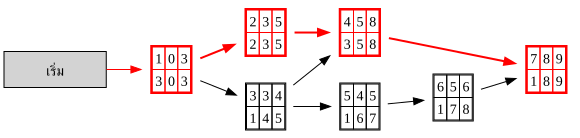


=== Activity on Arrow (AOA) ===


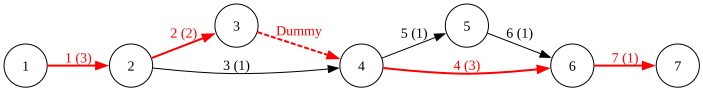

In [8]:
import pandas as pd
from graphviz import Digraph
from IPython.display import display

# 1. รับค่าข้อมูลจากตารางตามในภาพ
tasks = {
    1: {'name': 'ออกแบบและเสนอขออนุมัติเงินกู้', 'dur': 3, 'pred': []},
    2: {'name': 'ปรับพื้น', 'dur': 2, 'pred': [1]},
    3: {'name': 'สั่งวัสดุ', 'dur': 1, 'pred': [1]},
    4: {'name': 'ก่อสร้าง', 'dur': 3, 'pred': [2, 3]},
    5: {'name': 'เลือกสี', 'dur': 1, 'pred': [3]},
    6: {'name': 'เลือกพรม', 'dur': 1, 'pred': [5]},
    7: {'name': 'เก็บงาน', 'dur': 1, 'pred': [4, 6]}
}

# ---------------------------------------------------------
# 2. การคำนวณ ES, EF, LS, LF แบบอัตโนมัติ
# ---------------------------------------------------------

# Forward Pass (หา ES, EF)
for task_id, info in tasks.items():
    if not info['pred']:
        info['es'] = 0
    else:
        info['es'] = max([tasks[p]['ef'] for p in info['pred']])
    info['ef'] = info['es'] + info['dur']

# หาระยะเวลาสิ้นสุดโครงการรวม
project_duration = max([info['ef'] for info in tasks.values()])

# หา Successors (กิจกรรมที่ตามมา) เพื่อใช้คำนวณย้อนกลับ
for task_id in tasks:
    tasks[task_id]['succ'] = []
for task_id, info in tasks.items():
    for p in info['pred']:
        tasks[p]['succ'].append(task_id)

# Backward Pass (หา LS, LF)
for task_id in reversed(list(tasks.keys())):
    info = tasks[task_id]
    if not info['succ']:
        info['lf'] = project_duration
    else:
        info['lf'] = min([tasks[s]['ls'] for s in info['succ']])
    
    info['ls'] = info['lf'] - info['dur']
    info['slack'] = info['ls'] - info['es']
    info['is_critical'] = info['slack'] == 0

# ---------------------------------------------------------
# 3. สร้างแผนภาพ Activity on Node (AON)
# ---------------------------------------------------------
dot_aon = Digraph(comment='AON', format='png')
dot_aon.attr(rankdir='LR', size='10,5')
dot_aon.node('start', 'เริ่ม', shape='box', style='filled', fillcolor='lightgrey')

# สร้าง Node แบบตาราง 6 ช่อง ตามสไลด์
for task_id, info in tasks.items():
    color = 'red' if info['is_critical'] else 'black'
    penwidth = '2' if info['is_critical'] else '1'
    
    # HTML Table Label สำหรับ AON (โครงสร้าง: บน=ID|ES|EF, ล่าง=Dur|LS|LF)
    label = f"""<<TABLE BORDER="{penwidth}" CELLBORDER="1" CELLSPACING="0" COLOR="{color}">
      <TR><TD>{task_id}</TD><TD>{info['es']}</TD><TD>{info['ef']}</TD></TR>
      <TR><TD>{info['dur']}</TD><TD>{info['ls']}</TD><TD>{info['lf']}</TD></TR>
    </TABLE>>"""
    dot_aon.node(str(task_id), label=label, shape='plaintext')

# โยงเส้นความสัมพันธ์ AON
for task_id, info in tasks.items():
    if not info['pred']:
        dot_aon.edge('start', str(task_id), color='red' if info['is_critical'] else 'black')
    for p in info['pred']:
        # เส้นจะเป็นสีแดงถ้าทั้งจุดเริ่มต้นและจุดปลายทางอยู่บนเส้นทางวิกฤต
        edge_color = 'red' if tasks[p]['is_critical'] and info['is_critical'] else 'black'
        penwidth = '2' if edge_color == 'red' else '1'
        dot_aon.edge(str(p), str(task_id), color=edge_color, penwidth=penwidth)

# ---------------------------------------------------------
# 4. สร้างแผนภาพ Activity on Arrow (AOA)
# ---------------------------------------------------------
# หมายเหตุ: โครงสร้าง Event Nodes ของ AOA จะถูกแมปตามลักษณะภาพตัวอย่างในสไลด์ 
# เนื่องจากอัลกอริทึมสร้าง Dummy Activity อัตโนมัติมีความซับซ้อนสูง จึงจำลองโครงสร้างตามเป้าหมายของโจทย์

dot_aoa = Digraph(comment='AOA', format='png')
dot_aoa.attr(rankdir='LR', size='10,5')
dot_aoa.attr('node', shape='circle', fixedsize='true', width='0.6')

# สร้าง Nodes (Events) 1 ถึง 7
for i in range(1, 8):
    dot_aoa.node(str(i), str(i))

# กำหนดเส้นเชื่อม (Edges) พร้อมระบุกิจกรรมและระยะเวลา
edges = [
    ('1', '2', '1 (3)', 'red'),       # กิจกรรม 1
    ('2', '3', '2 (2)', 'red'),       # กิจกรรม 2
    ('2', '4', '3 (1)', 'black'),     # กิจกรรม 3
    ('3', '4', 'Dummy', 'red', 'dashed'), # Dummy
    ('4', '6', '4 (3)', 'red'),       # กิจกรรม 4
    ('4', '5', '5 (1)', 'black'),     # กิจกรรม 5
    ('5', '6', '6 (1)', 'black'),     # กิจกรรม 6
    ('6', '7', '7 (1)', 'red')        # กิจกรรม 7
]

for edge in edges:
    if len(edge) == 4:
        u, v, lbl, color = edge
        dot_aoa.edge(u, v, label=lbl, color=color, penwidth='2' if color=='red' else '1', fontcolor=color)
    else:
        u, v, lbl, color, style = edge
        dot_aoa.edge(u, v, label=lbl, color=color, style=style, penwidth='2' if color=='red' else '1', fontcolor=color)

# ---------------------------------------------------------
# 5. แสดงผลลัพธ์
# ---------------------------------------------------------
print("=== Activity on Node (AON) ===")
display(dot_aon)

print("\n=== Activity on Arrow (AOA) ===")
display(dot_aoa)